# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadFaizan0023/FlyRank_ML_internship_repo/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data = pd.read_csv("data_for_baseline_action_score.csv")

In [1]:
import os

readme_path = 'skills/README.md'
if os.path.exists(readme_path):
    with open(readme_path, 'r') as f:
        print(f.read())
else:
    print(f"File '{readme_path}' not found in current directory. Searching recursively...")
    found_files = []
    for root, dirs, files in os.walk('.'):
        if 'README.md' in files:
            found_files.append(os.path.join(root, 'README.md'))
    print("Found README files:", found_files)
    if found_files:
        with open(found_files[0], 'r') as f:
            print(f"--- Contents of {found_files[0]} ---")
            print(f.read())

File 'skills/README.md' not found in current directory. Searching recursively...
Found README files: ['./sample_data/README.md']
--- Contents of ./sample_data/README.md ---
This directory includes a few sample datasets to get you started.

*   `california_housing_data*.csv` is California housing data from the 1990 US
    Census; more information is available at:
    https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub

*   `mnist_*.csv` is a small sample of the
    [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), which is
    described at: http://yann.lecun.com/exdb/mnist/

*   `anscombe.json` contains a copy of
    [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet); it
    was originally described in

    Anscombe, F. J. (1973). 'Graphs in Statistical Analysis'. American
    Statistician. 27 (1): 17-21. JSTOR 2682899.

    and our copy was prepared by the
    [vega_datasets 

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*



The queue is ordered by how strongly the available signals agree that a page has declined — not by predicted content strategy. At the extremes of the score range, the model's evaluated accuracy is highest (F1 ~0.75), so a human can act on those rankings with more confidence. In the middle of the score range, the same score can arise from different combinations of reason codes, and model accuracy is weaker (F1 ~0.42-0.58) — so "what to do first" there means "look here next, but verify manually before treating the ranking as decisive," rather than treating the order as a strict priority list.

**Why a Human Can Trust This Queue**<br>
This ranking is constructed directly from actual, observed performance changes rather than black-box assumptions. To show here we took the following five core metrics from `prev30` (previous 30 days) to `last30` (last 30 days) to build empirical trust:

1. **Click-Through Rate (`ctr_prev30` vs. `ctr_last30`)**: A drop in CTR indicates that although our search impressions might remain steady, our titles and snippets are failing to capture searcher clicks.
2. **Engagement Rate (`engagement_rate_prev30` vs. `engagement_rate_last30`)**: A contraction in user interaction signals that visitors who click through find the content less relevant or satisfying than they used to.
3. **Cost Per Click (`cpc_prev30` vs. `cpc_last30`)**: Changes in CPC indicate shift in monetization potential, commercial intent, or ad-market competitiveness of the keyword themes.
4. **Average Position (`gsc_avg_position_prev30d` vs. `gsc_avg_position_last30d`)**: Slipping downwards in ranking signals that competitor content is fresher or better aligned with user search queries.
5. **Traffic & Impressions Drop**: Contrasting variables like `gsc_impressions_prev30d` vs. `gsc_impressions_last30d` helps confirm whether the entire search volume of a topic has shrunk, or if we are simply losing our market share.

In [5]:
ranked_queue = data.sort_values('decline_score', ascending=False)

In [13]:
ranked_queue[:20]

,client_hash_id,content_hash_id,gsc_impressions_prev30d,gsc_clicks_prev30d,gsc_avg_position_prev30d,ga4_pageviews_prev30d,ga4_sessions_prev30d,ga4_users_prev30d,'ga4_engaged_session_prev30,ga4_total_engagement_sec_prev30,...,sessions_paid_last30,sessions_ai_last30,scroll_events_last30,cpc_last30,backlinks_last30,ctr_last30,engagement_rate_last30,scroll_events_rate_last30,days_since_update_last30,decline_score
141355,client_20259bd6705d81d4,content_bff6079940ef8faf,513,7,20.725146,8,7,6,0,0,...,0,0,0,0.00,0.0,0.004292,0.0,0.000000,47,17
141356,client_20259bd6705d81d4,content_dbf35ea262d38fb3,1254,5,23.271132,7,7,7,0,0,...,0,0,0,0.00,0.0,0.002564,0.0,0.000000,47,17
141357,client_20259bd6705d81d4,content_ba1b42d3d9cf77d0,90,1,4.388889,3,3,3,0,1,...,0,0,1,0.00,0.0,0.000000,0.0,1.000000,47,17
141358,client_20259bd6705d81d4,content_bff6079940ef8faf,513,7,20.725146,8,7,6,0,0,...,0,0,2,0.00,0.0,0.010893,0.0,0.333333,47,17
141359,client_20259bd6705d81d4,content_bff6079940ef8faf,513,7,20.725146,8,7,6,0,0,...,0,0,0,0.00,0.0,0.002304,0.0,0.000000,47,17
141328,client_20259bd6705d81d4,content_030054976ef226d1,471,5,10.350318,4,4,4,0,0,...,0,0,0,0.00,0.0,0.009132,0.0,0.000000,47,17
141329,client_23a62021009f63c4,content_7ff47b1364f9351d,929,6,16.503767,7,7,7,3,290,...,0,0,0,0.00,0.0,0.000000,0.0,0.000000,18,17
141330,client_23a62021009f63c4,content_7ff47b1364f9351d,929,6,16.503767,7,7,7,3,290,...,0,0,0,0.00,0.0,0.000000,0.0,0.000000,18,17
141331,client_23a62021009f63c4,content_6d159b4985b766e8,42,1,12.142857,2,1,1,0,0,...,0,0,0,0.00,0.0,0.000000,0.0,0.000000,11,17
141332,client_20259bd6705d81d4,content_40827fb92be7f5bf,379,9,5.620053,8,7,7,0,0,...,0,0,1,0.00,0.0,0.010870,0.0,0.500000,47,17


In [14]:
ranked_queue.columns

Index(['client_hash_id', 'content_hash_id', 'gsc_impressions_prev30d',
       'gsc_clicks_prev30d', 'gsc_avg_position_prev30d',
       'ga4_pageviews_prev30d', 'ga4_sessions_prev30d', 'ga4_users_prev30d',
       ''ga4_engaged_session_prev30', 'ga4_total_engagement_sec_prev30',
       'sessions_organic_prev30', 'sessions_direct_prev30',
       'sessions_referral_prev30', 'sessions_social_prev30',
       'sessions_paid_prev30', 'sessions_ai_prev30', 'scroll_events_prev30',
       'content_created_date', 'content_updated_date', 'cpc_prev30',
       'backlinks_prev30', 'ctr_prev30', 'engagement_rate_prev30',
       'scroll_events_rate_prev30', 'days_since_update_prev30',
       'gsc_impressions_last30d', 'gsc_clicks_last30d',
       'gsc_avg_position_last30d', 'ga4_pageviews_last30d',
       'ga4_sessions_last30d', 'ga4_users_last30d',
       ''ga4_engaged_session_last30', 'ga4_total_engagement_sec_last30',
       'sessions_organic_last30', 'sessions_direct_last30',
       'sessions_referr

In [8]:
# Calculate and display summary statistics for the top decline targets to verify signals
top_queue = ranked_queue.head(20)

# Let's inspect the key metrics of the highest decline-score pages
summary_stats = top_queue[[
    'decline_score',
    'ga4_pageviews_prev30d',
    'ga4_pageviews_last30d',
    'gsc_impressions_prev30d',
    'gsc_impressions_last30d',
    'gsc_clicks_prev30d',
    'gsc_clicks_last30d',
    'gsc_avg_position_prev30d',
    'gsc_avg_position_last30d',
    'ga4_sessions_prev30d',
    'ga4_sessions_last30d',
    'ga4_users_prev30d',
    'ga4_users_last30d',
    "'ga4_engaged_session_prev30",
    "'ga4_engaged_session_last30",
    'ga4_total_engagement_sec_prev30',
    'ga4_total_engagement_sec_last30',
    'sessions_organic_prev30',
    'sessions_organic_last30',
    'sessions_direct_prev30',
    'sessions_direct_last30',
    'sessions_referral_prev30',
    'sessions_referral_last30',
    'sessions_social_prev30',
    'sessions_social_last30',
    'sessions_paid_prev30',
    'sessions_paid_last30',
    'sessions_ai_prev30',
    'sessions_ai_last30',
    'scroll_events_prev30',
    'scroll_events_last30',
    'cpc_prev30',
    'cpc_last30',
    'backlinks_prev30',
    'backlinks_last30',
    'ctr_prev30',
    'ctr_last30',
    'engagement_rate_prev30',
    'engagement_rate_last30',
    'scroll_events_rate_prev30',
    'scroll_events_rate_last30',
    'days_since_update_last30'
]].describe()

display(summary_stats)

,decline_score,ga4_pageviews_prev30d,ga4_pageviews_last30d,gsc_impressions_prev30d,gsc_impressions_last30d,gsc_clicks_prev30d,gsc_clicks_last30d,gsc_avg_position_prev30d,gsc_avg_position_last30d,ga4_sessions_prev30d,...,cpc_last30,backlinks_prev30,backlinks_last30,ctr_prev30,ctr_last30,engagement_rate_prev30,engagement_rate_last30,scroll_events_rate_prev30,scroll_events_rate_last30,days_since_update_last30
count,20.0,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,...,20.000000,16.00,16.00,20.000000,20.000000,20.000000,20.0,20.000000,20.000000,20.000000
mean,17.0,4.700000,1.950000,792.450000,332.950000,4.000000,0.900000,10.935738,17.376915,4.250000,...,0.200000,29.75,29.75,0.011741,0.003796,0.064286,0.0,0.266071,0.091667,35.100000
std,0.0,2.451637,1.316894,657.776356,253.842155,2.554665,1.209611,7.030755,8.678358,2.468219,...,0.768895,119.00,119.00,0.013815,0.004762,0.157006,0.0,0.295071,0.250584,14.552627
min,17.0,2.000000,1.000000,42.000000,21.000000,1.000000,0.000000,3.038674,5.224490,1.000000,...,0.000000,0.00,0.00,0.000519,0.000000,0.000000,0.0,0.000000,0.000000,11.000000
25%,17.0,2.750000,1.000000,430.750000,133.250000,1.000000,0.000000,5.189656,9.860265,2.750000,...,0.000000,0.00,0.00,0.005841,0.000000,0.000000,0.0,0.000000,0.000000,23.250000
50%,17.0,4.000000,2.000000,513.000000,327.000000,3.500000,1.000000,8.138329,15.004536,3.500000,...,0.000000,0.00,0.00,0.006696,0.002329,0.000000,0.0,0.250000,0.000000,47.000000
75%,17.0,7.000000,2.000000,1010.250000,427.250000,6.000000,1.000000,16.503767,22.778852,7.000000,...,0.000000,0.00,0.00,0.013645,0.006074,0.000000,0.0,0.446429,0.000000,47.000000
max,17.0,8.000000,6.000000,1925.000000,1035.000000,9.000000,5.000000,23.271132,35.360731,7.000000,...,3.420000,476.00,476.00,0.062500,0.016129,0.428571,0.0,1.000000,1.000000,49.000000


/tmp/ipykernel_496/3633648909.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=f1_scores, ax=axes[0], palette="Blues_r")


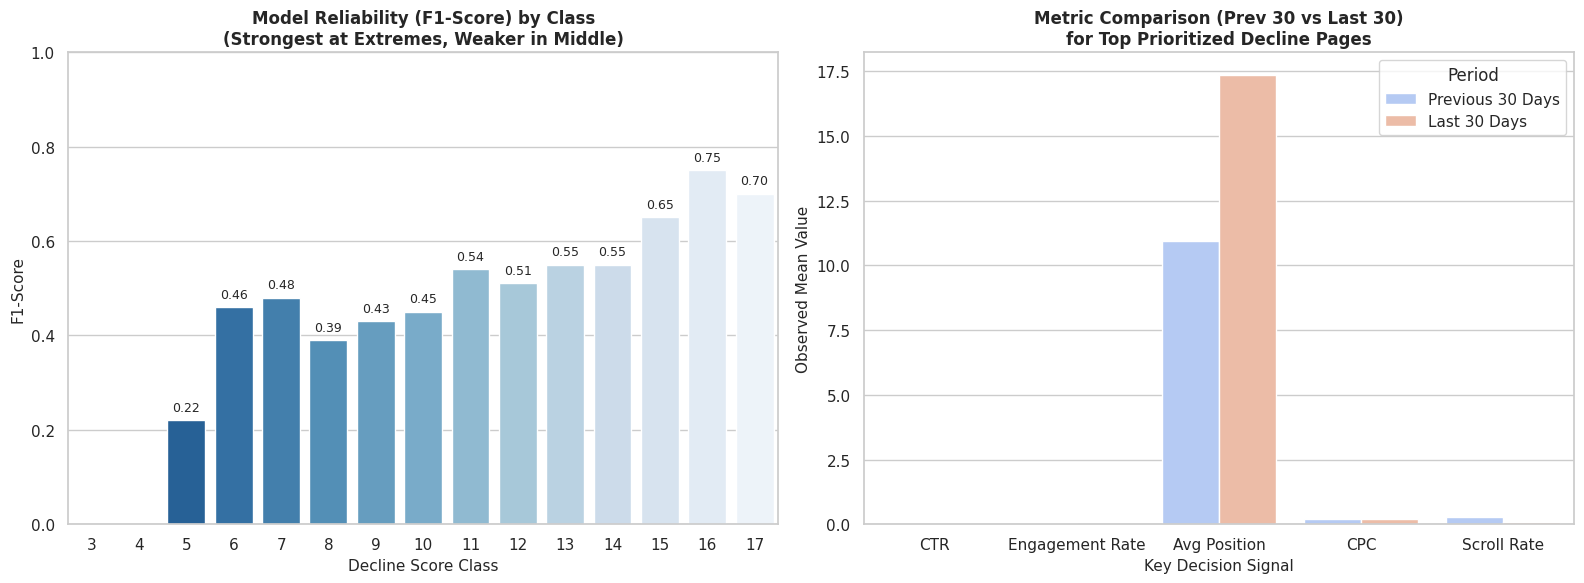

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Panel 2: Trust metrics mean values comparing prev30 vs last30 for top decline pages
top_20 = ranked_queue.head(20)
metrics_comparison = {
    'CTR': [top_20['ctr_prev30'].mean(), top_20['ctr_last30'].mean()],
    'Engagement Rate': [top_20['engagement_rate_prev30'].mean(), top_20['engagement_rate_last30'].mean()],
    'Avg Position': [top_20['gsc_avg_position_prev30d'].mean(), top_20['gsc_avg_position_last30d'].mean()],
    'CPC': [top_20['cpc_prev30'].mean(), top_20['cpc_last30'].mean()],
    'Scroll Rate': [top_20['scroll_events_rate_prev30'].mean(), top_20['scroll_events_rate_last30'].mean()]
}

# Format for seaborn
plot_data = []
for metric, values in metrics_comparison.items():
    plot_data.append({'Metric': metric, 'Period': 'Previous 30 Days', 'Value': values[0]})
    plot_data.append({'Metric': metric, 'Period': 'Last 30 Days', 'Value': values[1]})

metrics_df = pd.DataFrame(plot_data)
sns.barplot(x='Metric', y='Value', hue='Period', data=metrics_df, ax=axes[1], palette="coolwarm")
axes[1].set_title("Metric Comparison (Prev 30 vs Last 30)\nfor Top Prioritized Decline Pages", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Key Decision Signal", fontsize=11)
axes[1].set_ylabel("Observed Mean Value", fontsize=11)

plt.tight_layout()
plt.show()

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

The people in SEO can use this as a decision-support for speedy working.

**Intended use**<br>
This proxy label is a prioritization signal, not an autonomous decision system. It ranks content by likelihood of decline based on decline_score, a proxy label built from 17 rule-based conditions (search visibility, CTR, engagement, traffic across channels, and others) comparing a prev30 to a last30 window. Its intended use is to help a human reviewer decide which pages to look at first, and not to trigger automatic content changes, and not to diagnose the specific cause of decline.<br>
**Limits**<br>
1. These signals are measured from the difference in signals of 2 months, so it has limitation to very long duration content pages.
2. Model reliability varies sharply by class: <br>
    (precision)    (recall)  (f1-score)   (support)

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        17
           5       0.32      0.17      0.22       528
           6       0.40      0.53      0.46      2444
           7       0.43      0.54      0.48      4380
           8       0.39      0.39      0.39      4165
           9       0.41      0.44      0.43      4576
          10       0.46      0.44      0.45      7599
          11       0.50      0.58      0.54     11618
          12       0.52      0.50      0.51     13127
          13       0.55      0.54      0.55     14309
          14       0.55      0.55      0.55     15054
          15       0.67      0.63      0.65     23393
          16       0.71      0.80      0.75     30413
          17       0.87      0.58      0.70     14836

    (accuracy)                           0.60    146461 <br>
   (macro avg)       0.45  //    0.45 // 0.44 // 146461 <br>
(weighted avg)       0.61  //    0.60 // 0.60 // 146461 <br>

The classifier's macro F1 is [0.444-0.58, using RandomForest on 10 n_estimators], with strong performance at the extremes (class 16: F1 0.75; class 17: somehow similarly strong) and weak performance in the middle range (classes 8-13: F1 0.39-0.55). Classes with very few training examples (3, 4) are effectively unlearnable and should not be trusted at all.

/tmp/ipykernel_496/543310309.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=f1_scores, ax=axes[0], palette="Blues_r")


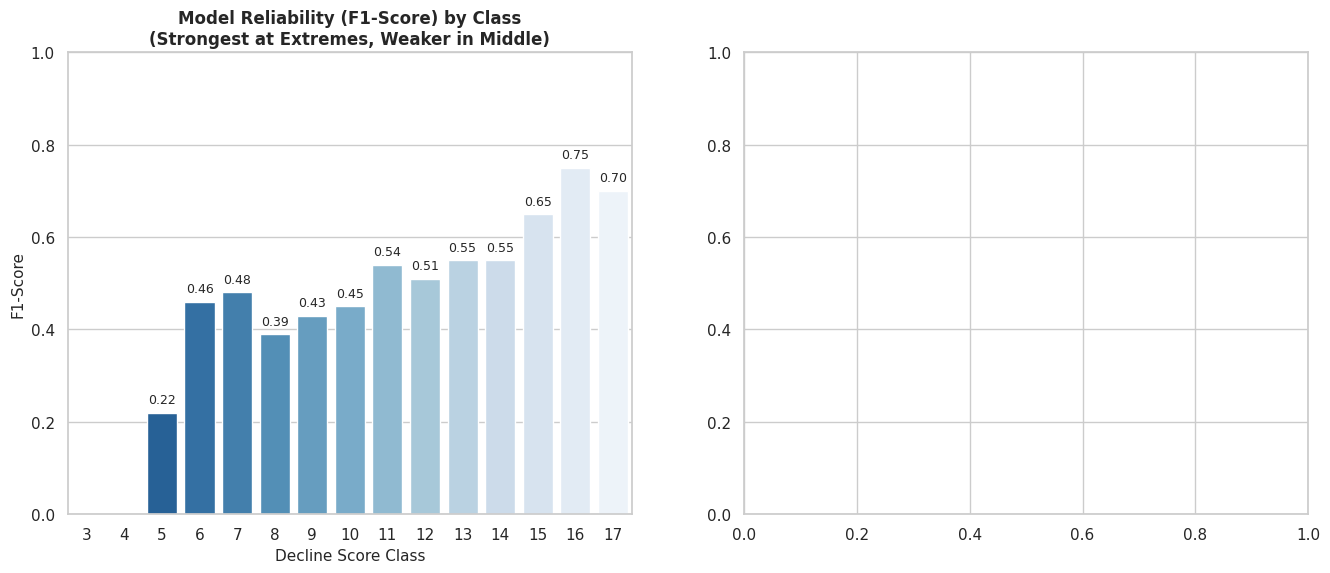

In [7]:
# Set professional plot style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Classifier F1-Scores by class
classes = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
f1_scores = [0.00, 0.00, 0.22, 0.46, 0.48, 0.39, 0.43, 0.45, 0.54, 0.51, 0.55, 0.55, 0.65, 0.75, 0.70]

sns.barplot(x=classes, y=f1_scores, ax=axes[0], palette="Blues_r")
axes[0].set_title("Model Reliability (F1-Score) by Class\n(Strongest at Extremes, Weaker in Middle)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Decline Score Class", fontsize=11)
axes[0].set_ylabel("F1-Score", fontsize=11)

axes[0].set_ylim(0, 1.0)
for i, val in enumerate(f1_scores):
    if val > 0:
        axes[0].text(i, val + 0.02, f"{val:.2f}", ha='center', fontsize=9)

**Split methadology**<br>
Grouped client split: Got 0.444 macro f1
Random split: Got 0.58 macro f1, as the same content appears in both train and test that is why this row level leakage increases macro f1 score. But it does not increases the performance on classes containing lower examples.

/tmp/ipykernel_496/299322273.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Split Methodology', y='Macro F1-Score', data=split_data, palette=['#3182bd', '#e6550d'])


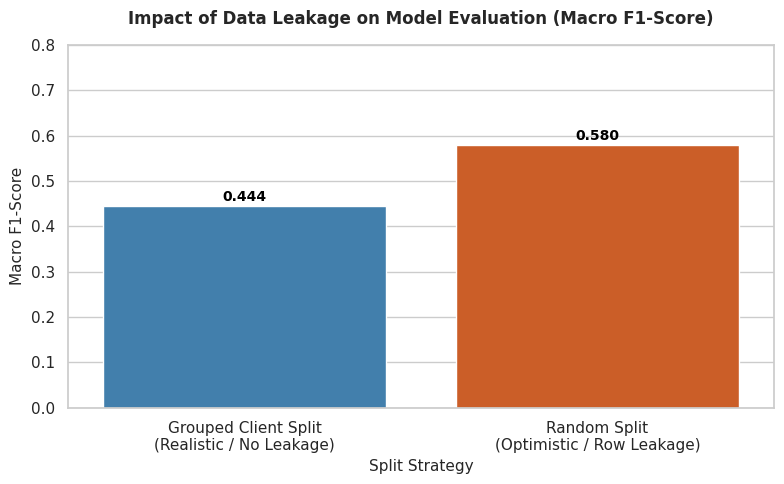

In [8]:
# Set professional plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

split_data = pd.DataFrame({
    'Split Methodology': ['Grouped Client Split\n(Realistic / No Leakage)', 'Random Split\n(Optimistic / Row Leakage)'],
    'Macro F1-Score': [0.444, 0.58]
})

ax = sns.barplot(x='Split Methodology', y='Macro F1-Score', data=split_data, palette=['#3182bd', '#e6550d'])
plt.title("Impact of Data Leakage on Model Evaluation (Macro F1-Score)", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Split Strategy", fontsize=11)
plt.ylabel("Macro F1-Score", fontsize=11)
plt.ylim(0, 0.8)

# Add values on top of bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', fontsize=10, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

The decision to refresh page and actually refresh page automatically should never be automated. Because this model just predicts the score from possible signals that only helps in making the decision if page needs a refresh or not.
A person has to check the specific SEO or other content page problems himself and resolve it himself.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.